<a href="https://colab.research.google.com/github/sidharth463/24BSE1211-PDE-MicroProject-Group-14-/blob/main/Microproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# SAINTGITS COLLEGE OF ENGINEERING (AUTONOMOUS)
### Department of Electronics and Communication Engineering
**Course:** 24BSE2113-D Partial Differential Equations, Transforms & Optimization Techniques  
**Course Coordinator:** Siju K S  

---

## MICRO-PROJECT PHASE 2: Computational Simulation & Analysis
### Topic: Isotropic Diffusion of Pixel Intensity (1D Heat Equation)

**Submitted By:** Group 14  

| Sl. No. | Roll No. | Student Name |
| :---: | :---: | :--- |
| 1 | 63 | Sidharth S |
| 2 | 65 | Sourav R |
| 3 | 68 | Thomas Mathew |
| 4 | 59 | Shaheem Ahammed |
| 5 | 64 | Sivapriya K G |

---
# **Micro-Project: 1D Image Blurring Simulation (The Heat Equation)**

##**1. Aim**
To simulate and computationally analyze the isotropic diffusion of pixel intensity along a 1D digital image scan line using the exact Fourier series solution derived in Phase 1.

## **2. Objective**
* To implement a numerical model in Python (numpy and matplotlib) visualizing pixel intensity diffusion over time.
* To verify how high-frequency spatial components decay exponentially faster than lower-frequency components.
* To observe the Gibbs phenomenon near the sharp edge transition at $t = 0$.
* To demonstrate how the 1D heat equation acts physically as a continuous spatial low-pass filter.

## **3. Computational Algorithm & Methodology**
1. **Initialize Parameters:** Set scan line length $L = 1.0$, diffusion coefficient $\alpha = 0.02$, peak initial intensity $I_0 = 1.0$, and number of Fourier terms $N = 150$.
2. **Define Spatial Domain:** Generate $x \in [0, L]$ using np.linspace.
3. **Compute Fourier Sine Coefficients:** Using the exact formula derived in Phase 1:$$b_n = \frac{2 I_0}{n\pi} \left[1 - \cos\left(\frac{n\pi}{2}\right)\right]$$
4. **Evaluate Temporal Decay & Spatial Eigenfunctions:** For each mode $n$, calculate:$$\text{Spatial factor} = \sin\left(\frac{n\pi x}{L}\right)$$$$\text{Temporal factor} = \exp\left(-\alpha \frac{n^2 \pi^2}{L^2} t\right)$$
5. **Sum Fourier Series:** Compute $I(x, t) = \sum_{n=1}^{N} b_n \sin\left(\frac{n\pi x}{L}\right) \exp\left(-\alpha \frac{n^2 \pi^2}{L^2} t\right)$.
6. **Visualization:** Plot $I(x,t)$ across time steps $t = 0.0, 0.1, 0.5$ to illustrate blur progression.

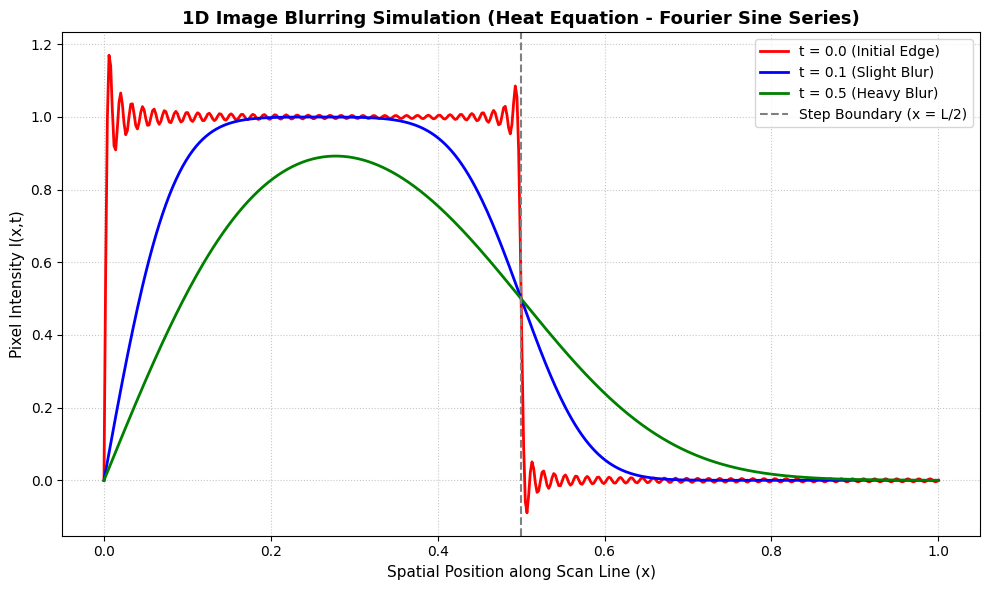

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def fourier_series_blur(x, t, L=1.0, alpha=0.02, I0=1.0, terms=150):
    """
    Computes the 1D heat equation solution using the exact Fourier Sine Series
    derived in Phase 1 for an initial step profile: I(x,0) = I0 for 0 < x < L/2.
    """
    intensity = np.zeros_like(x)

    for n in range(1, terms + 1):
        # Fourier coefficient derived in Phase 1
        bn = (2.0 * I0 / (n * np.pi)) * (1.0 - np.cos(n * np.pi / 2.0))

        # Spatial eigenfunction and temporal decay
        spatial = np.sin(n * np.pi * x / L)
        temporal = np.exp(-alpha * (n**2 * np.pi**2 / L**2) * t)

        # Superposition of modes
        intensity += bn * spatial * temporal

    return intensity

# --- Simulation Parameters ---
L = 1.0          # Length of scan line
alpha = 0.02     # Diffusion coefficient
I0 = 1.0         # Initial step intensity
N_terms = 150    # Number of Fourier series terms
x_vals = np.linspace(0, L, 500)

# Time steps to evaluate
time_steps = [0.0, 0.1, 0.5]
colors = ['red', 'blue', 'green']
labels = ['t = 0.0 (Initial Edge)', 't = 0.1 (Slight Blur)', 't = 0.5 (Heavy Blur)']

# --- Plotting Setup ---
plt.figure(figsize=(10, 6))

for t, color, label in zip(time_steps, colors, labels):
    y_vals = fourier_series_blur(x_vals, t, L=L, alpha=alpha, I0=I0, terms=N_terms)
    plt.plot(x_vals, y_vals, color=color, label=label, linewidth=2)

# Graph Formatting
plt.title("1D Image Blurring Simulation (Heat Equation - Fourier Sine Series)", fontsize=13, fontweight='bold')
plt.xlabel("Spatial Position along Scan Line (x)", fontsize=11)
plt.ylabel("Pixel Intensity I(x,t)", fontsize=11)
plt.axvline(x=L/2, color='gray', linestyle='--', label='Step Boundary (x = L/2)')
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Render plot
plt.show()

## 4. Demonstrating the Low-Pass Filtering Effect (Harmonic Decay)

To rigorously verify why high-frequency terms cause blurring, we isolate individual spatial harmonics $n$ and observe their temporal decay factor derived in Phase 1:
$$H_n(t) = \exp\left(-\alpha \frac{n^2 \pi^2}{L^2} t\right)$$

On a logarithmic scale, higher harmonics (larger $n$) plunge toward zero exponentially faster due to the quadratic $n^2$ dependency, mathematically demonstrating the low-pass filtering mechanism of diffusion.

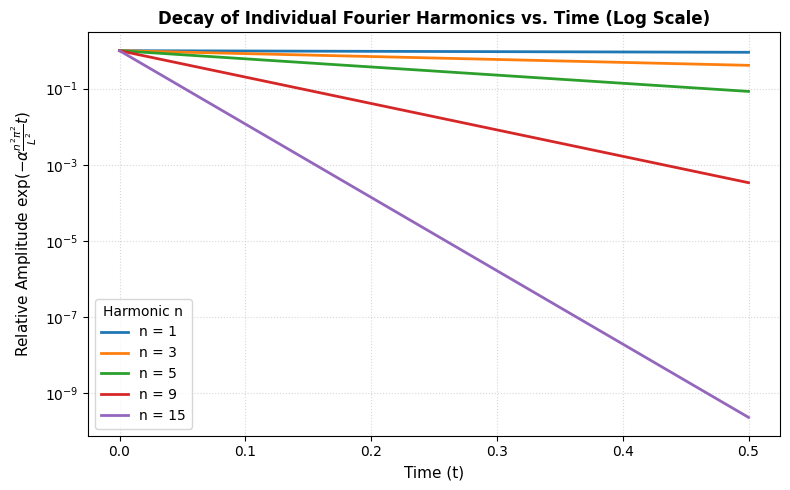

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Parameters matching Group 14 Phase 1 ---
alpha = 0.02
L = 1.0
t_vals = np.linspace(0, 0.5, 200)

# Selected spatial harmonics to compare
n_values = [1, 3, 5, 9, 15]

# --- Plotting Harmonic Decay ---
plt.figure(figsize=(8, 5))

for n in n_values:
    # Temporal decay factor from Group 14 Phase 1 Equation (32)
    decay = np.exp(-alpha * (n**2 * np.pi**2 / L**2) * t_vals)
    plt.plot(t_vals, decay, label=f'n = {n}', linewidth=2)

# Graph Formatting
plt.title("Decay of Individual Fourier Harmonics vs. Time (Log Scale)", fontsize=12, fontweight='bold')
plt.xlabel("Time (t)", fontsize=11)
plt.ylabel(r"Relative Amplitude $\exp(-\alpha \frac{n^2\pi^2}{L^2} t)$", fontsize=11)
plt.yscale("log")
plt.legend(title="Harmonic n", fontsize=10)
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.tight_layout()

# Render plot
plt.show()

## **5. Physical Interpretation & Engineering Conclusions**
* **Behavior at $t = 0$ (Gibbs Phenomenon):** At initial time $t = 0$, the series truncated at $N = 150$ terms shows minor high-frequency overshoot/undershoot oscillations near $x = L/2$. This is a classic mathematical feature of Fourier approximations when representing discontinuous step functions.
* **Exponential Suppression of High Frequencies:** The temporal decay factor $T_n(t) = \exp\left(-\alpha \frac{n^2 \pi^2}{L^2} t\right)$ depends quadratically on $n^2$. Consequently, higher spatial harmonics (responsible for sharp transitions) attenuate drastically fast.
* **Low-Pass Filtering Effect:** As diffusion time $t$ increases ($t = 0.1 \rightarrow 0.5$), the sharp discontinuity dissolves into a smooth sigmoidal transition curve. Mathematically, the heat equation functions as an isotropic spatial low-pass filter, smoothing high-frequency spatial gradients while preserving low-frequency energy profiles across the scan line.